In [19]:
!cp /content/urdu_embeddings_from_tuned_xlmr_final.csv /content/drive/MyDrive/urdu_embeddings_from_tuned_xlmr_final.csv

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VideoEncoder(nn.Module):
    def __init__(self, video_dim, hidden_dim):
        super(VideoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(video_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.encoder(x)


class TextEncoder(nn.Module):
    def __init__(self, text_dim, hidden_dim):
        super(TextEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(text_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.encoder(x)


class VideoTextEmotionPredictor(nn.Module):
    def __init__(self, video_dim, text_dim, common_space_dim, hidden_dim, num_classes):
        super(VideoTextEmotionPredictor, self).__init__()

        self.video_encoder = VideoEncoder(video_dim, hidden_dim)
        self.text_encoder = TextEncoder(text_dim, hidden_dim)

        self.video_proj = nn.Sequential(
            nn.Linear(hidden_dim, common_space_dim),
            nn.LayerNorm(common_space_dim)
        )
        self.text_proj = nn.Sequential(
            nn.Linear(hidden_dim, common_space_dim),
            nn.LayerNorm(common_space_dim)
        )

        self.classifier = nn.Sequential(
            nn.Linear(common_space_dim * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, video_features, text_features):
        video_hidden = self.video_encoder(video_features)
        text_hidden = self.text_encoder(text_features)

        z_v = self.video_proj(video_hidden)
        z_t = self.text_proj(text_hidden)

        alignment_loss = 1 - F.cosine_similarity(z_v, z_t, dim=-1).mean()

        combined = torch.cat([z_v, z_t], dim=-1)
        emotion_logits = self.classifier(combined)

        return emotion_logits, alignment_loss

In [2]:
import pandas as pd

# 1. Load the files
df_text = pd.read_csv('/content/urdu_embeddings_from_tuned_xlmr_final.csv')
df_video = pd.read_csv('/content/drive/MyDrive/videomae_features.csv')
print(df_text.shape)
print(df_video.shape)

(8293, 770)
(8587, 770)


**Merge Datasets**

In [4]:
import pandas as pd
import os

# Load datasets

video_df = pd.read_csv("/content/drive/MyDrive/videomae_features.csv")
text_df = pd.read_csv("/content/urdu_embeddings_from_tuned_xlmr_final.csv")

# Extract filenames only

video_df = video_df.rename(columns={'Link': 'Link_video', 'Label': 'Label_video'})
text_df = text_df.rename(columns={'Link': 'Link_text', 'Label': 'Label_text'})

def clean_video_id(link_path):
    if pd.isna(link_path):
        return None

    base = os.path.splitext(os.path.basename(str(link_path)))[0]
    parts = base.split('_')

    if len(parts) >= 3:
        return f"{parts[0]}_{parts[1]}_{parts[2]}"
    return base

def clean_text_id(link_path):
    if pd.isna(link_path):
        return None
    base = os.path.splitext(os.path.basename(str(link_path)))[0]
    parts = base.split('_')
    if len(parts) >= 3:
        return f"{parts[0]}_{parts[1]}_{parts[2]}"
    return base
video_df["ID"] = video_df["Link_video"].apply(clean_video_id)

text_df["ID"] = text_df["Link_text"].apply(clean_text_id)

text_df = text_df.drop_duplicates(subset="ID", keep="first")
video_df = video_df.drop_duplicates(subset="ID", keep="first")

# Check sample IDs

print(video_df["ID"].head())
print(text_df["ID"].head())

# Merge datasets

merged_df = video_df.merge(text_df, on="ID", how="inner")

# Final shape

print("Merged shape:", merged_df.shape)

0    Neutral_5_1602.682015-1611.024811
1       Anger_39_431.904295-439.059992
2      Anger_147_412.160229-419.563514
3         Love_251_46.430398-53.978573
4         Sad_18_631.677016-634.386207
Name: ID, dtype: object
0               Anger_102_0-6.625516
1    Anger_10_1393.359356-1398.19227
2     Anger_11_855.179326-861.899282
3                Anger_12_0-6.061702
4    Anger_12_1130.953564-1136.57101
Name: ID, dtype: object
Merged shape: (8267, 1541)


In [5]:
video_ids = set(video_df["ID"])
text_ids = set(text_df["ID"])

common_ids = video_ids & text_ids

print("Common IDs:", len(common_ids))

Common IDs: 8267


In [6]:
print(merged_df['Label_video'].value_counts())
print(merged_df['Label_text'].value_counts())

Label_video
Anger      2070
Happy      1773
Neutral    1657
Sad        1632
Love       1135
Name: count, dtype: int64
Label_text
Anger      2070
Happy      1773
Neutral    1657
Sad        1632
Love       1135
Name: count, dtype: int64


In [7]:
mismatched = merged_df[
    (merged_df['Label_video'] != merged_df['Label_text'])
]

print(f"Total rows checking: {len(merged_df)}")
print(f"Mismatched rows : {len(mismatched)}")

if len(mismatched) > 0:
    import pandas as pd
    pd.set_option('display.max_colwidth', None)

    print("\n======= MISMATCHED SAMPLES REPORT =======")
    print(mismatched[['ID', 'Label_video', 'Label_text']].head(30))
else:
    print("\n now labels matched perfectly!")

Total rows checking: 8267
Mismatched rows : 0

✅ now labels matched perfectly!


In [8]:
merged_df = merged_df[
    (merged_df['Label_video'] == merged_df['Label_text'])
]

In [ ]:
merged_df.columns

Index(['Link_video', 'Label_video', 'V_0', 'V_1', 'V_2', 'V_3', 'V_4', 'V_5',
       'V_6', 'V_7',
       ...
       't_760', 't_761', 't_762', 't_763', 't_764', 't_765', 't_766', 't_767',
       'Link_text', 'Label_text'],
      dtype='object', length=1541)

In [9]:
from sklearn.preprocessing import LabelEncoder
# --- 1. Identify Columns Correctly ---

# Text columns
text_cols = [col for col in merged_df.columns if col.isdigit()]

# Video columns
video_cols = [f"V_{i}" for i in range(768) if f"V_{i}" in merged_df.columns]

# --- Verification ---
print(f"Verified Text Columns: {len(text_cols)} (Expected: 768)")
print(f"Verified Video Columns: {len(video_cols)} (Expected: 256)")

# --- 2. Extract Data to Numpy Arrays ---
text_features = merged_df[text_cols].values
video_features = merged_df[video_cols].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(merged_df['Label_video'].astype(str))
# --- Final Shape ---
print(f"Final Shape - Text: {text_features.shape}, Video: {video_features.shape}, Labels: {y_encoded.shape}")

Verified Text Columns: 768 (Expected: 768)
Verified Video Columns: 768 (Expected: 256)
Final Shape - Text: (8267, 768), Video: (8267, 768), Labels: (8267,)


**Train test split**

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

text_train, text_test, video_train, video_test, y_train, y_test = train_test_split(text_features, video_features, y_encoded, test_size=0.2, random_state=42)

**Scaling**

In [11]:
scaler_text = StandardScaler()
scaler_video = StandardScaler()

# Text scaling
text_train_scaled = scaler_text.fit_transform(text_train)
text_test_scaled = scaler_text.transform(text_test)

# Video scaling
video_train_scaled = scaler_video.fit_transform(video_train)
video_test_scaled = scaler_video.transform(video_test)

In [12]:
# Training Tensors
text_train_t = torch.tensor(text_train, dtype=torch.float32)
video_train_t = torch.tensor(video_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

# Testing Tensors
text_test_t = torch.tensor(text_test, dtype=torch.float32)
video_test_t = torch.tensor(video_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)



In [13]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(video_train_t, text_train_t, y_train_t)
test_dataset = TensorDataset(video_test_t, text_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [14]:
text_dim = text_train_t.shape[1]
video_dim = video_train_t.shape[1]

model = VideoTextEmotionPredictor(
    video_dim=video_dim,
    text_dim=text_dim,
    common_space_dim=128,
    hidden_dim=256,
    num_classes=len(set(y_encoded))
)

In [15]:
import numpy as np
import torch
import torch.nn as nn
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ALIGN_WEIGHT = 0.1
epochs = 100
PATIENCE = 7

optimizer = torch.optim.Adam(model.parameters(), lr=3e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

# Weighted CrossEntropyLoss for class imbalance
label_counts = Counter(y_train)
total_samples = sum(label_counts.values())
class_weights = torch.tensor(
    [total_samples / label_counts[i] for i in range(5)],
    dtype=torch.float32
).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

best_val_loss = float('inf')
patience_counter = 0

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0

    for v, t, y in train_loader:
        v, t, y = v.to(device), t.to(device), y.to(device)

        optimizer.zero_grad()

        outputs, align_loss = model(v, t)
        cls_loss = criterion(outputs, y)

        # Alignment loss warmup scheduler
        align_weight = ALIGN_WEIGHT * (epoch / epochs)
        loss = cls_loss + align_weight * align_loss

        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)


    # --- VALIDATION PHASE ---
    model.eval()
    total_val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for v_val, t_val, y_val in test_loader:
            v_val, t_val, y_val = v_val.to(device), t_val.to(device), y_val.to(device)

            outputs_val, align_loss_val = model(v_val, t_val)
            cls_val_loss = criterion(outputs_val, y_val)

            val_loss = cls_val_loss + (ALIGN_WEIGHT * 0.5) * align_loss_val
            total_val_loss += val_loss.item()

            _, predicted = torch.max(outputs_val.data, 1)
            total += y_val.size(0)
            correct += (predicted == y_val).sum().item()

    avg_val_loss = total_val_loss / len(test_loader)
    accuracy = 100 * correct / total

    # LR Scheduler updates correctly now
    scheduler.step(avg_val_loss)

    # Early stopping evaluation based on a stable metric
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n Early stopping triggered at epoch {epoch+1}")
            break

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {accuracy:.2f}%")
    print(f"Align Loss (last batch): {align_loss.item():.4f} | Dynamic Weight: {align_weight:.4f}")
    print("-" * 30)

Epoch [1/100]
Train Loss: 1.5293 | Val Loss: 1.4149 | Val Acc: 49.33%
Align Loss (last batch): 0.9734 | Dynamic Weight: 0.0000
------------------------------
Epoch [2/100]
Train Loss: 1.3204 | Val Loss: 1.2356 | Val Acc: 57.80%
Align Loss (last batch): 1.0361 | Dynamic Weight: 0.0010
------------------------------
Epoch [3/100]
Train Loss: 1.1898 | Val Loss: 1.1671 | Val Acc: 58.16%
Align Loss (last batch): 0.9876 | Dynamic Weight: 0.0020
------------------------------
Epoch [4/100]
Train Loss: 1.1341 | Val Loss: 1.1461 | Val Acc: 58.65%
Align Loss (last batch): 1.0203 | Dynamic Weight: 0.0030
------------------------------
Epoch [5/100]
Train Loss: 1.1085 | Val Loss: 1.1304 | Val Acc: 58.89%
Align Loss (last batch): 1.0056 | Dynamic Weight: 0.0040
------------------------------
Epoch [6/100]
Train Loss: 1.0853 | Val Loss: 1.1182 | Val Acc: 59.79%
Align Loss (last batch): 0.9498 | Dynamic Weight: 0.0050
------------------------------
Epoch [7/100]
Train Loss: 1.0635 | Val Loss: 1.1011 

In [16]:
correct = 0
total = 0

with torch.no_grad():
    for v, t, y in test_loader:
        v, t, y = v.to(device), t.to(device), y.to(device)
        outputs, align_loss = model(v, t)
        _, predicted = torch.max(outputs, 1)

        total += y.size(0)
        correct += (predicted == y).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 62.27%


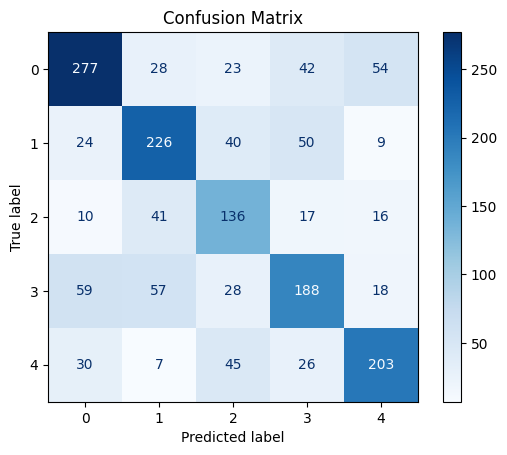

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for v, t, y in test_loader:
        v, t = v.to(device), t.to(device)
        outputs, align= model(v, t)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

NameError: name 'model' is not defined

**k Fold**

In [18]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, SubsetRandomSampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
import copy

# --- Setup ---
BATCH_SIZE = 32
EPOCHS     = 30
LR         = 3e-5
N_FOLDS    = 5
ALIGN_W    = 0.3
PATIENCE   = 10

from sklearn.preprocessing import StandardScaler

scaler_text = StandardScaler()
scaler_video = StandardScaler()

text_features = scaler_text.fit_transform(text_features)
video_features = scaler_video.fit_transform(video_features)
# Convert to tensors once (outside fold loop — efficient)
X_video  = torch.tensor(video_features, dtype=torch.float32)
X_text   = torch.tensor(text_features,  dtype=torch.float32)
y        = torch.tensor(y_encoded,          dtype=torch.long)

dataset  = TensorDataset(X_video, X_text, y)
skf      = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# --- Results Storage ---
fold_results = []

# --- K-Fold Loop ---
for fold, (train_idx, val_idx) in enumerate(skf.split(
        np.zeros(len(y)), y.numpy())):

    print(f"\n{'='*40}")
    print(f"  FOLD {fold+1}/{N_FOLDS}")
    print(f"{'='*40}")
    print(f"Train: {len(train_idx)} | Val: {len(val_idx)}")

    # Fresh model for every fold — critical
    model = VideoTextEmotionPredictor(
        video_dim=768,
        text_dim=768,
        common_space_dim=128,
        hidden_dim=512,
        num_classes=5
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(), lr=LR, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 'min', patience=3, factor=0.5
    )
    counts = np.bincount(y[train_idx].numpy())
    weights = 1.0 / torch.tensor(counts, dtype=torch.float32)
    weights = weights / weights.sum() * len(counts) # Normalize
    criterion = nn.CrossEntropyLoss(weight=weights.to(device))

    # Samplers
    train_loader = DataLoader(dataset, batch_size=BATCH_SIZE,
                              sampler=SubsetRandomSampler(train_idx))
    val_loader   = DataLoader(dataset, batch_size=BATCH_SIZE,
                              sampler=SubsetRandomSampler(val_idx))

    # Early stopping state
    best_val_loss   = float('inf')
    patience_counter = 0
    best_model_wts  = copy.deepcopy(model.state_dict())

    # --- Epoch Loop ---
    for epoch in range(EPOCHS):
        # Training
        model.train()
        total_train_loss = 0

        for v, t, labels_batch in train_loader:
            v, t, labels_batch = v.to(device), t.to(device), labels_batch.to(device)

            optimizer.zero_grad()
            logits, align_loss = model(v, t)
            cls_loss = criterion(logits, labels_batch)

            align_weight = ALIGN_W * (epoch / EPOCHS)  # warmup
            loss = cls_loss + align_weight * align_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_train_loss += loss.item()

        # Validation
        model.eval()
        total_val_loss = 0
        correct = 0
        total   = 0

        with torch.no_grad():
            for v, t, labels_batch in val_loader:
                v, t, labels_batch = v.to(device), t.to(device), labels_batch.to(device)
                logits, align_loss = model(v, t)

                cls_loss   = criterion(logits, labels_batch)
                align_weight = ALIGN_W * (epoch / EPOCHS)
                val_loss   = cls_loss + align_weight * align_loss

                total_val_loss += val_loss.item()
                _, predicted = torch.max(logits, 1)
                total   += labels_batch.size(0)
                correct += (predicted == labels_batch).sum().item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss   = total_val_loss   / len(val_loader)
        accuracy       = 100 * correct / total

        scheduler.step(avg_val_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}] "
                  f"Train: {avg_train_loss:.4f} | "
                  f"Val: {avg_val_loss:.4f} | "
                  f"Acc: {accuracy:.2f}%")

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss    = avg_val_loss
            patience_counter = 0
            best_model_wts   = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    # --- Fold Evaluation on best checkpoint ---
    model.load_state_dict(best_model_wts)
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for v, t, labels_batch in val_loader:
            v, t, labels_batch = v.to(device), t.to(device), labels_batch.to(device)
            logits, _ = model(v, t)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    report = classification_report(
        all_labels, all_preds,
        target_names=['Anger', 'Happy', 'Neutral', 'Sad', 'Love'],
        output_dict=True
    )

    fold_acc = report['accuracy'] * 100
    fold_f1  = report['macro avg']['f1-score']
    fold_results.append({'accuracy': fold_acc, 'f1': fold_f1, 'report': report})

    print(f"\nFold {fold+1} Best → Acc: {fold_acc:.2f}% | F1: {fold_f1:.4f}")
    print(classification_report(
        all_labels, all_preds,
        target_names=['Anger', 'Happy', 'Neutral', 'Sad', 'Love']
    ))

    # Save each fold's best model
    torch.save(best_model_wts, f'best_model_fold{fold+1}.pt')

# --- Final Summary ---
print(f"\n{'='*40}")
print("  K-FOLD FINAL SUMMARY")
print(f"{'='*40}")
accs = [r['accuracy'] for r in fold_results]
f1s  = [r['f1']       for r in fold_results]

for i, r in enumerate(fold_results):
    print(f"Fold {i+1}: Acc={r['accuracy']:.2f}% | F1={r['f1']:.4f}")

print(f"\nMean Accuracy: {np.mean(accs):.2f}% ± {np.std(accs):.2f}%")
print(f"Mean F1:       {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")


  FOLD 1/5
Train: 6613 | Val: 1654
Epoch [1/30] Train: 1.4521 | Val: 1.2284 | Acc: 59.07%
Epoch [5/30] Train: 0.9911 | Val: 1.0033 | Acc: 63.48%
Epoch [10/30] Train: 0.7944 | Val: 0.9995 | Acc: 65.36%
Epoch [15/30] Train: 0.6710 | Val: 1.0432 | Acc: 65.72%
  Early stopping at epoch 17

Fold 1 Best → Acc: 64.57% | F1: 0.6417
              precision    recall  f1-score   support

       Anger       0.74      0.68      0.71       414
       Happy       0.68      0.63      0.65       355
     Neutral       0.57      0.64      0.60       227
         Sad       0.54      0.58      0.56       332
        Love       0.68      0.69      0.68       326

    accuracy                           0.65      1654
   macro avg       0.64      0.64      0.64      1654
weighted avg       0.65      0.65      0.65      1654


  FOLD 2/5
Train: 6613 | Val: 1654
Epoch [1/30] Train: 1.4689 | Val: 1.2419 | Acc: 59.79%
Epoch [5/30] Train: 0.9939 | Val: 1.0186 | Acc: 62.70%
Epoch [10/30] Train: 0.7940 | Val: 1.0